# Exploratory Data Analysis: Part 2

Goal of this notebook is to surface out whether the feature set I have prepared in the previous notebook contains any predictive value for Bitcoin accumulation signal.

In [1269]:
# Dependencies
from contextlib import contextmanager
from datetime import datetime
from datetime import date, timedelta
from pathlib import Path
from typing import Optional
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
import eda_starter as eda
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from xgboost import XGBRegressor, XGBClassifier
import shap

import itertools
import signal_helper as signal
from eda.signal_helper import merge_ROI_rank
from template.prelude_template import BACKTEST_START
import ta
import btc_helper as help

In [1548]:
import importlib
importlib.reload(signal)

<module 'signal_helper' from 'C:\\Users\\timot\\OneDrive\\Learn\\GT OMSA\\Practicum\\eda\\signal_helper.py'>

## 1. Data and Definitions

In [1549]:
# Import data
btc_df = pl.read_parquet("btc_df_final.parquet")

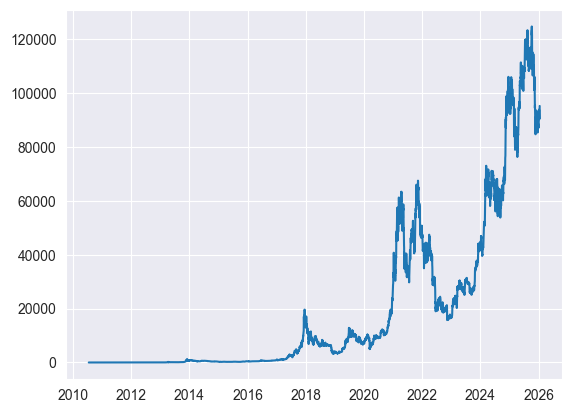

In [1254]:
plt.plot(btc_df['time'], btc_df['PriceUSD'])

Column Definitions

In [1529]:
COLS = btc_df.columns
EXCLUDE_COLS = ['time','future_30d_avg',
                'ROI_30d_avg',
                'target_up_30d',
                'target_up5_30d',
                'future_30d_vs_30d_SMA',
                'future_30d_min',
                'Price_per_30d_min',
                'target_rank_30d',
                'future_60d_avg',
                'ROI_60d_avg',
                'target_up_60d',
                'target_up5_60d',
                'future_60d_vs_30d_SMA',
                'future_60d_min',
                'Price_per_60d_min',
                'target_rank_60d',
                'ROI_30d',
                'ROI_30d_top30',
                'ROI_60d',
                'ROI_60d_top30','markPrice',
                'PriceUSD',
                'target_up_30d',
                'CapMrktCurUSD',
                'oc_MVRV_high',
                'future_30d_kmin_5',
                'future_60d_kmin_5',
                'Future_30d_min_rel',
                'Future_60d_min_rel',
                # 'smastd_200',
                # 'distance_sma_200'
                #'oc_CapMrktCurUSD_Z',
                ]
TARGET_COL = 'target_up5_60d'
INDEX_COL = 'time_basis'

# FEATURE_COLS = 'oc_MVRVCur_Z'
FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL]
POLYMARKET_COL = [
    'poly_dtrade_count',
    'poly_dtrade_active_traders',
    'poly_dtrade_avg_trx',
    'poly_dtrade_trx',
    'poly_dtrade_trx_dir',
    'poly_dtrade_trx_std',
    'odds_markets',
    'odds_avg',
    'odds_dispersion',
    'odds_breadth',
    'odds_momentum',
    'odds_long_market',
    'odds_long_avg',
    'odds_short_market',
    'odds_short_avg',
    'odds_duration_divergence',
    'poly_dtrade_trx_zscore',
    'poly_dtrade_trx_dir_zscore',
    'odds_avg_zscore',
    'odds_long_zscore',
    'odds_short_zscore',
    'poly_dtrade_trx_dir_ratio',
]
NON_POLY_FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL and col not in POLYMARKET_COL]
POLYMARKET_START = pl.date(2025,4,7)

ONCHAIN_FEATURES = [
    'AdrActCnt',
    'AdrBalCnt',
    'BlkCnt',
    'CapMVRVCur',
    'FeeTotNtv',
    'HashRate',
    'TxCnt',
    'TxTfrCnt',
    'volume_reported_spot_usd_1d',
    'oc_MVRVCur_Z',
    'oc_MVRVCur_grad',
    'oc_MVRVCur_accel',
    'oc_CapMrktCurUSD_Z',
    'oc_MVRVCur_vol_Z',
    'oc_Puell_proxy',
    'oc_miner_stress',
    'oc_flow_ratio',
    'oc_vol_30d_Z',
    'oc_turnover',
]
TECHNICAL_FEATURES = [
    'smastd_200',
    'distance_sma_200',
    'emastd_200',
    'distance_ema_200',
    'drawdown',
    'RSI',
    'RSI_zscore',
]
MACRO_FEATURES = [
    'M2SL',
    'WALCL',
    'CPIAUCSL',
    'fed_balance_growth',
    'real_rate',
    'usd_strength',
    '10y_yield',
    'inflation_yoy'
]
BINANCE_FEATURES = [
    'bin_returns_1d',
    'bin_volatility_30d',
    'bin_volume_zscore',
    'funding_rate'
]

In [1599]:
btc_df.columns

['time',
 'AdrActCnt',
 'AdrBalCnt',
 'BlkCnt',
 'CapMVRVCur',
 'CapMrktCurUSD',
 'FeeTotNtv',
 'HashRate',
 'PriceUSD',
 'TxCnt',
 'TxTfrCnt',
 'volume_reported_spot_usd_1d',
 'time_basis',
 'oc_MVRVCur_Z',
 'oc_MVRVCur_grad',
 'oc_MVRVCur_accel',
 'oc_MVRVCur_vol_Z',
 'oc_CapMrktCurUSD_Z',
 'oc_MVRV_high',
 'oc_Puell_proxy',
 'oc_miner_stress',
 'oc_flow_ratio',
 'oc_vol_30d_Z',
 'oc_turnover',
 'smastd_200',
 'distance_sma_200',
 'emastd_200',
 'distance_ema_200',
 'drawdown',
 'RSI',
 'RSI_zscore',
 'M2SL',
 'WALCL',
 'CPIAUCSL',
 'fed_balance_growth',
 'real_rate',
 'usd_strength',
 '10y_yield',
 'inflation_yoy',
 'funding_rate',
 'markPrice',
 'bin_returns_1d',
 'bin_volatility_30d',
 'bin_volume_zscore',
 'poly_dtrade_count',
 'poly_dtrade_active_traders',
 'poly_dtrade_avg_trx',
 'poly_dtrade_trx',
 'poly_dtrade_trx_dir',
 'poly_dtrade_trx_std',
 'odds_markets',
 'odds_avg',
 'odds_dispersion',
 'odds_breadth',
 'odds_momentum',
 'odds_long_market',
 'odds_long_avg',
 'odds_sho

## 2. Base Model, All Data

In [1017]:
X = btc_df[FEATURE_COLS]
y = btc_df[TARGET_COL]
ROI = btc_df[['ROI_60d_avg']]
n_fold = 4
tscv = TimeSeriesSplit(n_splits= n_fold)
X_train, X_test, y_train, y_test, ROI_train, ROI_test = train_test_split(X, y, ROI, test_size=0.2,
                                                                         random_state=42, shuffle=False)

### 2.1. XGBoost

In [388]:
model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.1],
    'colsample_bytree': [0.6, 0.8],
    'subsample': [0.6, 0.8],
    'reg_lambda': [1, 1.5, 2],
    'reg_alpha': [0, 0.1, 1],
}

In [389]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy', # Choose an appropriate scoring metric
    cv=tscv,
    verbose=1,
    return_train_score=True,
    n_jobs=-1 # Use all available CPU cores
)

grid_search.fit(X_train, y_train)

Fitting 4 folds for each of 432 candidates, totalling 1728 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.6, 0.8], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [300, 500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [390]:
print(grid_search.best_params_)
model = grid_search.best_estimator_
# {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.6}

{'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': 0.6}


In [391]:
rank = signal.get_rank(model, X, len(X_train), 60) # Include purge mechanism to avoid data leak
ROI_rank = signal.merge_ROI_rank(ROI, rank)

(-0.5, 1.5)

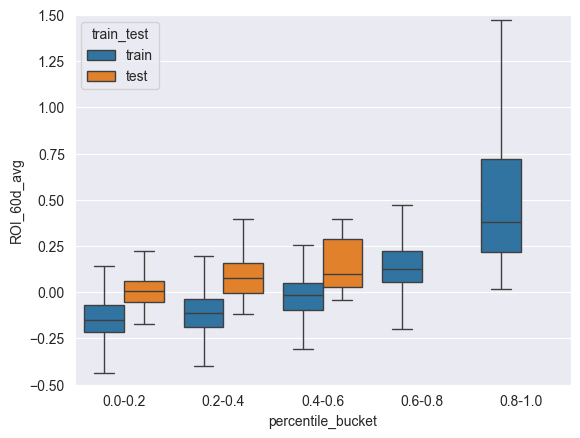

In [392]:
sns.boxplot(x="percentile_bucket", y="ROI_60d_avg",
            hue="train_test", order=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
            data=ROI_rank, fliersize=0)
plt.ylim(-0.5, 1.5)

(-0.5, 1.5)

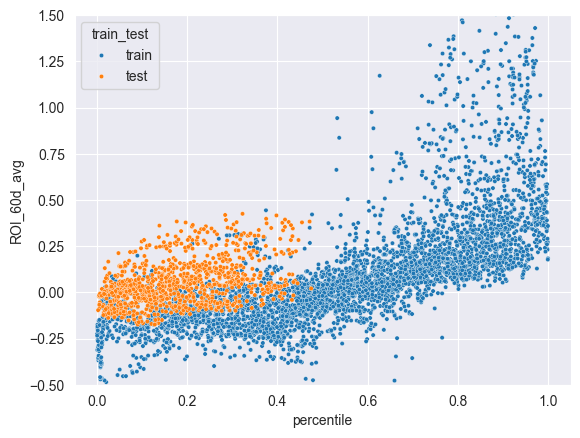

In [393]:
sns.scatterplot(ROI_rank.to_pandas().sort_values(by="train_test", ascending=False), x="percentile", y="ROI_60d_avg", hue="train_test", s=10)
plt.ylim(-0.5, 1.5)

The model probability output is ranked into 5 buckets from low to high and joined with ROI_60d_avg
Each bucket's ROI_60d_avg mean shows monotonic increase indicating the model was able to identify the factors which can increase ROI despite not having high confidence

percentile_bucket,train,test
str,f64,f64
"""0.0-0.2""",-0.151168,0.014034
"""0.2-0.4""",-0.100408,0.090969
"""0.4-0.6""",-0.023855,0.15571
"""0.6-0.8""",0.192116,null
"""0.8-1.0""",0.714157,null


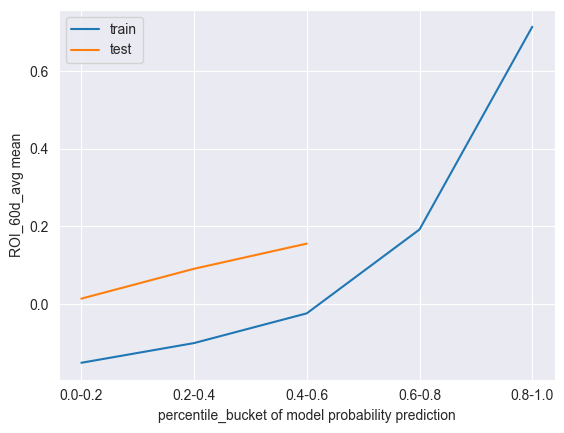

In [394]:
signal.plot_ROI_by_bucket(ROI_rank)

percentile_bucket,test,train
str,f64,f64
"""0.0-0.2""",0.524957,0.083643
"""0.2-0.4""",0.736573,0.186536
"""0.4-0.6""",0.829268,0.439366
"""0.6-0.8""",null,0.892226
"""0.8-1.0""",null,1.0


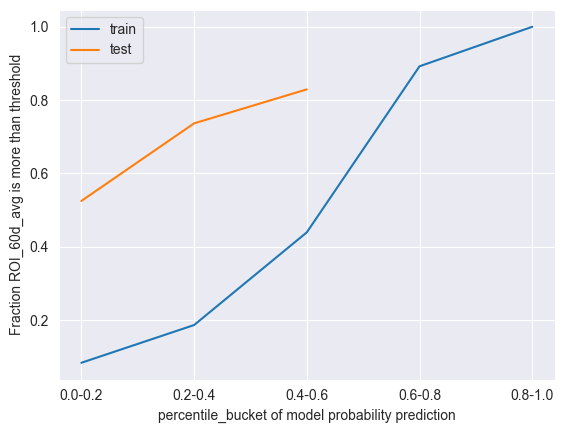

In [395]:
signal.plot_ROI_threshold(ROI_rank,0)

Fairly monotonic increase in ROI, strong indication that the current dataset contains good Bitcoin accumulation signal

In [45]:
background = X.to_pandas().sample(min(200, len(X)), random_state=42)
background.columns = [str(c) for c in background.columns]

X_shap = X.to_pandas()
X_shap.columns = [str(c) for c in X_shap.columns]

explainer = shap.TreeExplainer(
    model,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_shap)


100%|===================| 5632/5659 [00:47<00:00]        

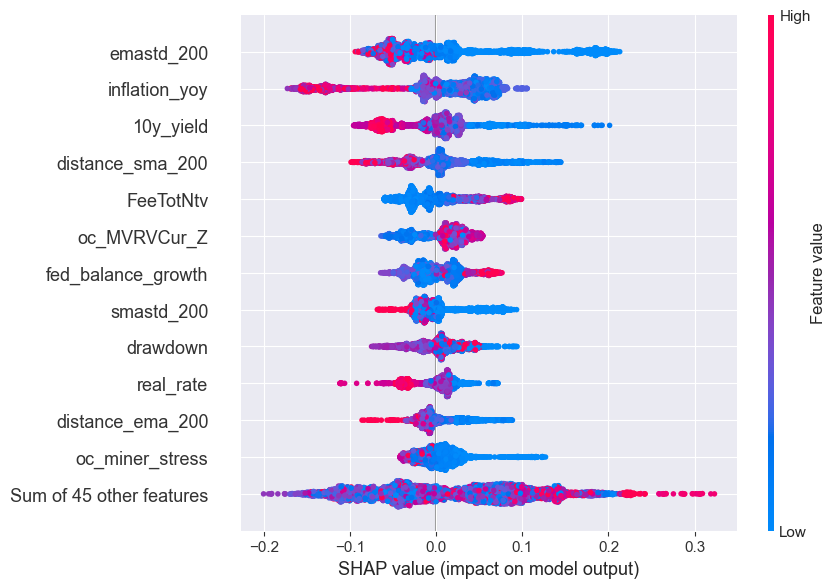

In [50]:
shap.plots.beeswarm(shap_values, max_display=13)

Top features and possible explanations

| Feature name | Model favors feature value which is | Possible explanation |
| -------- |-------------------------------------|---|
| emastd_200 | low                                 | low volatility is less risky for accumulation |
| inflation_yoy | low                                 | favorable for economic growth |
| 10y_yield | low | x |
| distance_sma_200 | low | buy when cheaper |
| FeeTotNtv | high | high network usage |
| oc_MVRVCur_Z | high | probably captures momentum instead of value signal |
| fed_balance_growth | high |x |
| smastd_200 | low | low volatility is less risky for accumulation |
| drawdown | low | buy when cheaper |
| real_rate | low | favorable for economic growth |
| distance_ema_200 | low | buy when cheaper |
| oc_miner_stress | low | falling hashrates coincide with high mining difficulty and low Bitcoin prices |


In [47]:
shap_col = pl.DataFrame({'colname':X.columns, 'shap':np.abs(shap_values.values).mean(axis=0)})
shap_col.with_columns(
    pl.when(pl.col('colname').is_in(POLYMARKET_COL)).then(pl.lit('POLYMARKET'))
    .when(pl.col('colname').is_in(ONCHAIN_FEATURES)).then(pl.lit('ONCHAIN'))
    .when(pl.col('colname').is_in(BINANCE_FEATURES)).then(pl.lit('BINANCE'))
    .when(pl.col('colname').is_in(TECHNICAL_FEATURES)).then(pl.lit('TECHNICAL'))
    .when(pl.col('colname').is_in(MACRO_FEATURES)).then(pl.lit('MACRO'))
    .alias('COL_CATEGORY')
).group_by(pl.col('COL_CATEGORY')).agg(pl.col('shap').sum()/shap_col['shap'].sum())

COL_CATEGORY,shap
str,f64
"""BINANCE""",0.011963
"""MACRO""",0.343385
"""POLYMARKET""",0.0
"""TECHNICAL""",0.312612
"""ONCHAIN""",0.33204


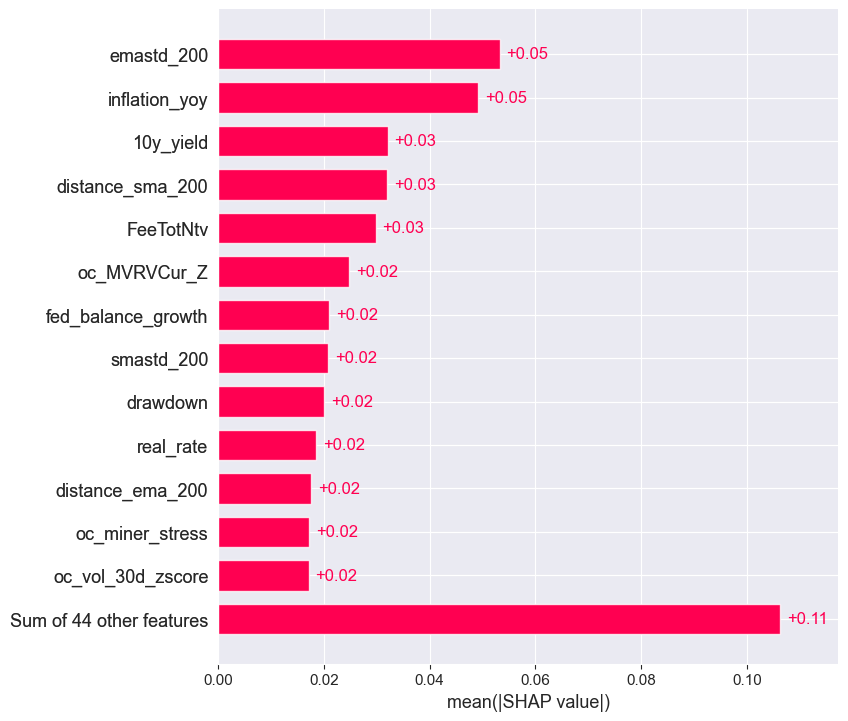

In [48]:
shap.plots.bar(shap_values, max_display=14)

3250it [01:14, 37.71it/s]                          


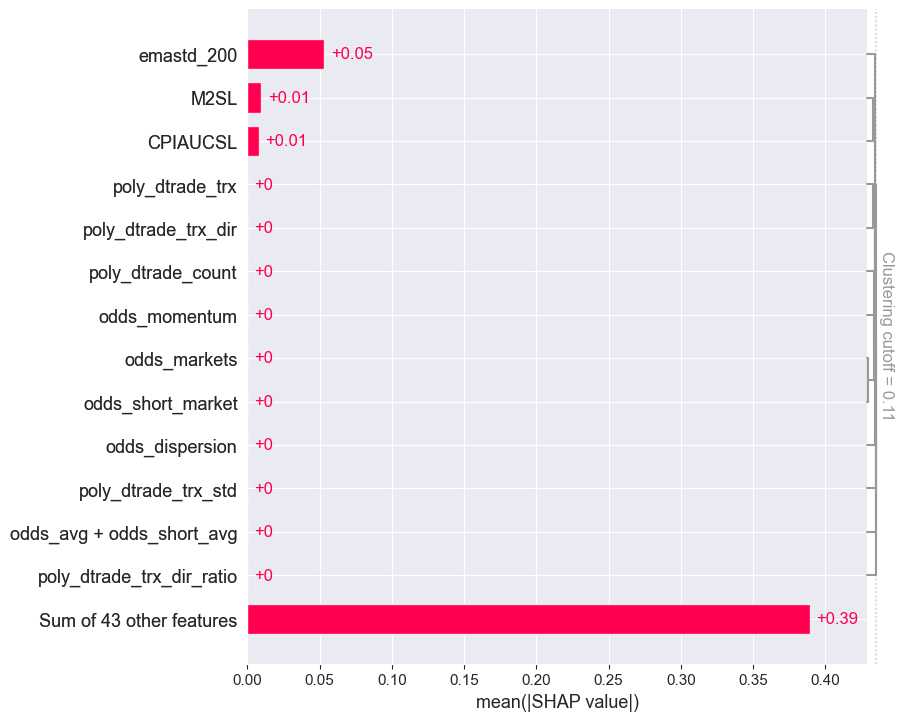

In [49]:
# Clustering combines too many features together
# Results indicate the XGBoost model is a "distributed" model with no few features dominating the rest
# The polymarket data are showing zero because they were not available in the training dataset, these have to be analyzed separately for specific time period
clustering = shap.utils.hclust(X, y)
shap.plots.bar(shap_values, max_display=14, clustering=clustering, clustering_cutoff=0.11)

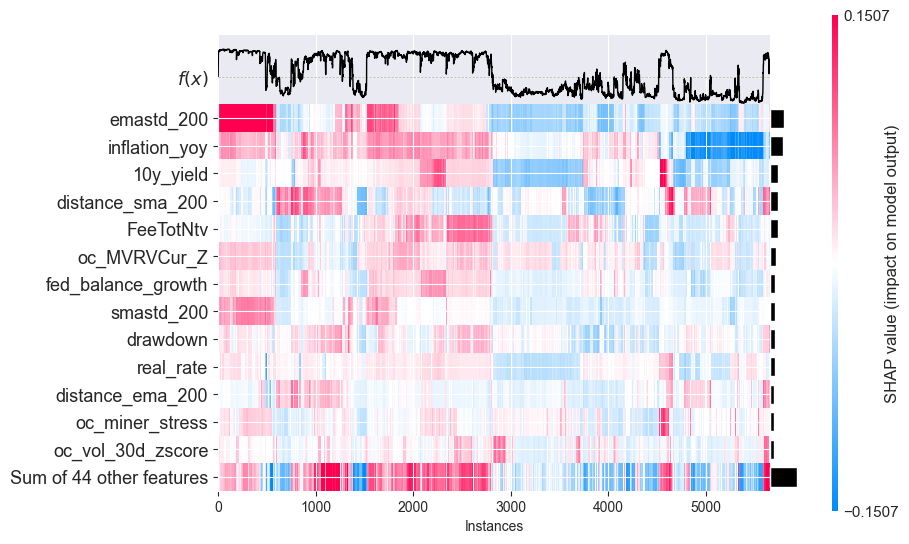

<Axes: xlabel='Instances'>

In [51]:
shap.plots.heatmap(shap_values, max_display=14)

### 2.2. Logistic Regression

Poor results

In [52]:
model_LR = LogisticRegression(max_iter=1000,random_state=42)
model_LR.fit(X_train, y_train)
rank_LR = signal.get_rank(model_LR, X, len(X_train))
ROI_rank_LR = signal.merge_ROI_rank(ROI, rank_LR)

(-0.5, 1.5)

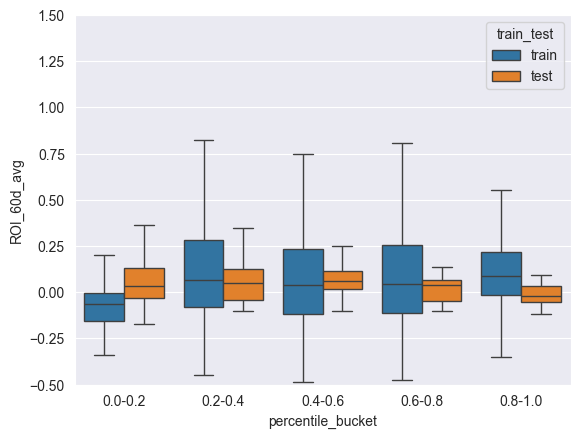

In [53]:
sns.boxplot(x="percentile_bucket", y="ROI_60d_avg",
            hue="train_test", order=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
            data=ROI_rank_LR, fliersize=0)
plt.ylim(-0.5, 1.5)

### 2.3. Random Forest

In [54]:
model_RF = RandomForestClassifier(random_state=42, criterion='log_loss')
param_grid_RF = {
    'max_depth': [3, 5, 7],
    'n_estimators': [300, 500, 700],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search_RF = GridSearchCV(
    estimator=model_RF,
    param_grid=param_grid_RF,
    scoring='accuracy', # Choose an appropriate scoring metric
    cv=tscv,
    verbose=1,
    return_train_score=True,
    n_jobs=-1 # Use all available CPU cores
)

grid_search_RF.fit(X_train, y_train)

Fitting 4 folds for each of 72 candidates, totalling 288 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [2, 4], 'min_samples_split': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [55]:
print(grid_search_RF.best_params_)
model_RF = grid_search_RF.best_estimator_
rank_RF = signal.get_rank(model_RF, X, len(X_train), 60)
ROI_rank_RF = signal.merge_ROI_rank(ROI, rank_RF)

{'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}


(-0.5, 1.5)

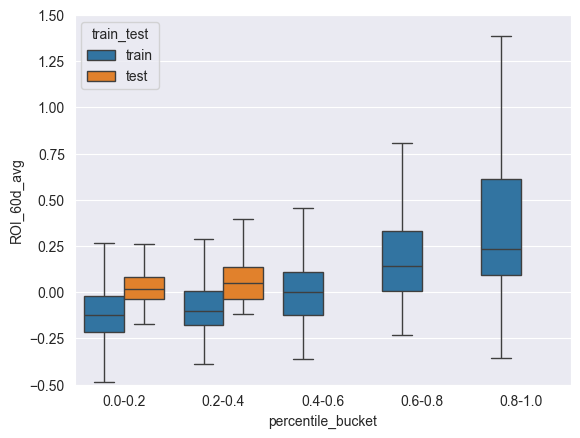

In [56]:
sns.boxplot(x="percentile_bucket", y="ROI_60d_avg",
            hue="train_test", order=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
            data=ROI_rank_RF, fliersize=0)
plt.ylim(-0.5, 1.5)

### 2.4 LightGBM

In [58]:
model_LGB = LGBMClassifier(random_state=42, objective = 'binary')
param_grid_LGB = {
    'max_depth': [5, 7],
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.1],
    'colsample_bytree': [0.6, 0.8],
    'subsample': [0.6, 0.8],
    'reg_lambda': [1.5, 2],
    'reg_alpha': [0.1, 1],
}

grid_search_LGB = GridSearchCV(
    estimator=model_LGB,
    param_grid=param_grid_LGB,
    scoring='accuracy', # Choose an appropriate scoring metric
    cv=tscv,
    verbose=1,
    return_train_score=True,
    n_jobs=-1 # Use all available CPU cores
)

grid_search_LGB.fit(X_train.to_pandas(), y_train.to_pandas())

Fitting 4 folds for each of 128 candidates, totalling 512 fits
[LightGBM] [Info] Number of positive: 2731, number of negative: 1796
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8273
[LightGBM] [Info] Number of data points in the train set: 4527, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.603269 -> initscore=0.419106
[LightGBM] [Info] Start training from score 0.419106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.6, 0.8], 'learning_rate': [0.01, 0.1], 'max_depth': [5, 7], 'n_estimators': [300, 500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [59]:
print(grid_search_LGB.best_params_)
model_LGB = grid_search_LGB.best_estimator_
# {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1.5, 'subsample': 0.6}

{'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1.5, 'subsample': 0.6}


In [60]:
rank_LGB = signal.get_rank(model_LGB, X, len(X_train), 60)
ROI_rank_LGB = signal.merge_ROI_rank(ROI, rank_LGB)

(-0.5, 1.5)

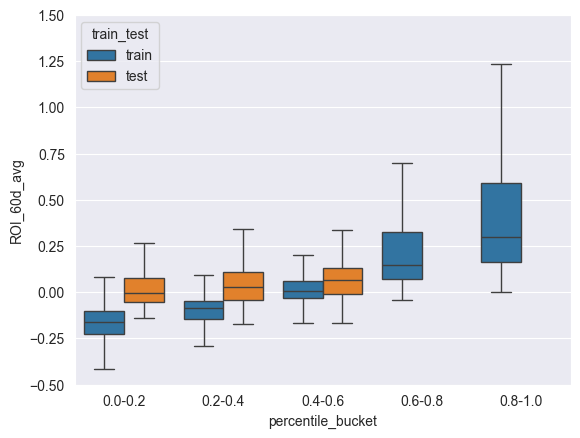

In [61]:
sns.boxplot(x="percentile_bucket", y="ROI_60d_avg",
            hue="train_test", order=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
            data=ROI_rank_LGB, fliersize=0)
plt.ylim(-0.5, 1.5)

percentile_bucket,test,train
str,f64,f64
"""0.0-0.2""",0.024576,-0.168514
"""0.2-0.4""",0.043476,-0.087568
"""0.4-0.6""",0.079722,0.027295
"""0.6-0.8""",null,0.284677
"""0.8-1.0""",null,0.62832


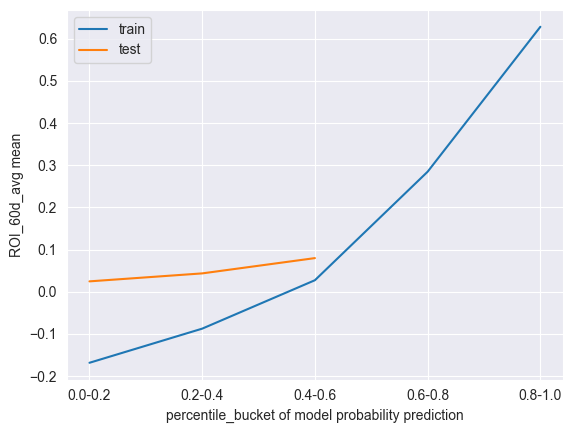

In [62]:
signal.plot_ROI_by_bucket(ROI_rank_LGB)

percentile_bucket,test,train
str,f64,f64
"""0.0-0.2""",0.488235,0.013528
"""0.2-0.4""",0.608177,0.071161
"""0.4-0.6""",0.730469,0.584541
"""0.6-0.8""",null,0.992933
"""0.8-1.0""",null,1.0


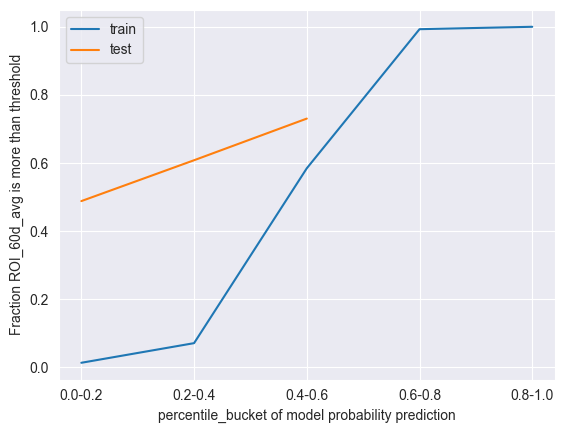

In [63]:
signal.plot_ROI_threshold(ROI_rank_LGB,0)

In [495]:
background = X.to_pandas().sample(min(200, len(X)), random_state=42)
background.columns = [str(c) for c in background.columns]

X_shap = X.to_pandas()
X_shap.columns = [str(c) for c in X_shap.columns]

explainer_LGB = shap.TreeExplainer(
    model_LGB,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values_LGB = explainer_LGB(X_shap)
clustering = shap.utils.hclust(X, y)

3250it [01:16, 37.56it/s]                                


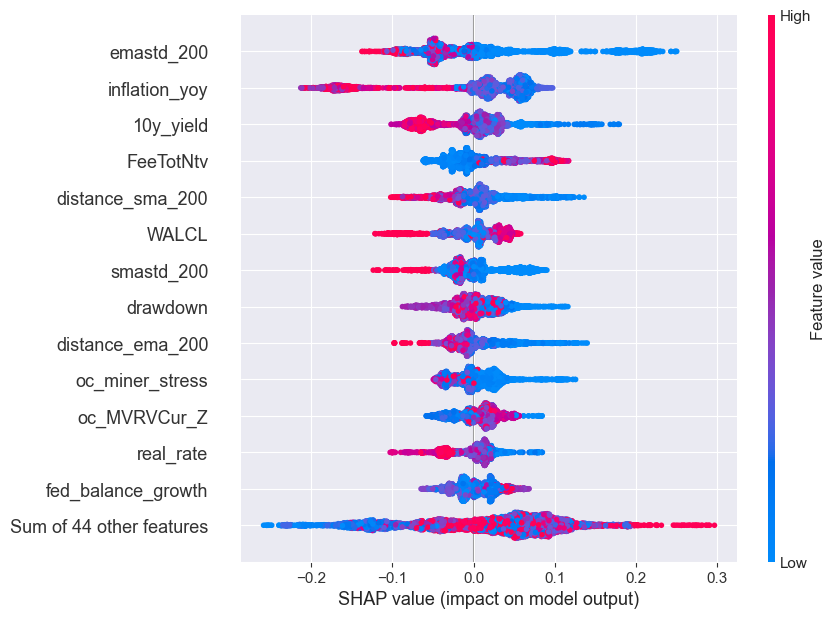

In [498]:
shap.plots.beeswarm(shap_values_LGB, max_display=14)

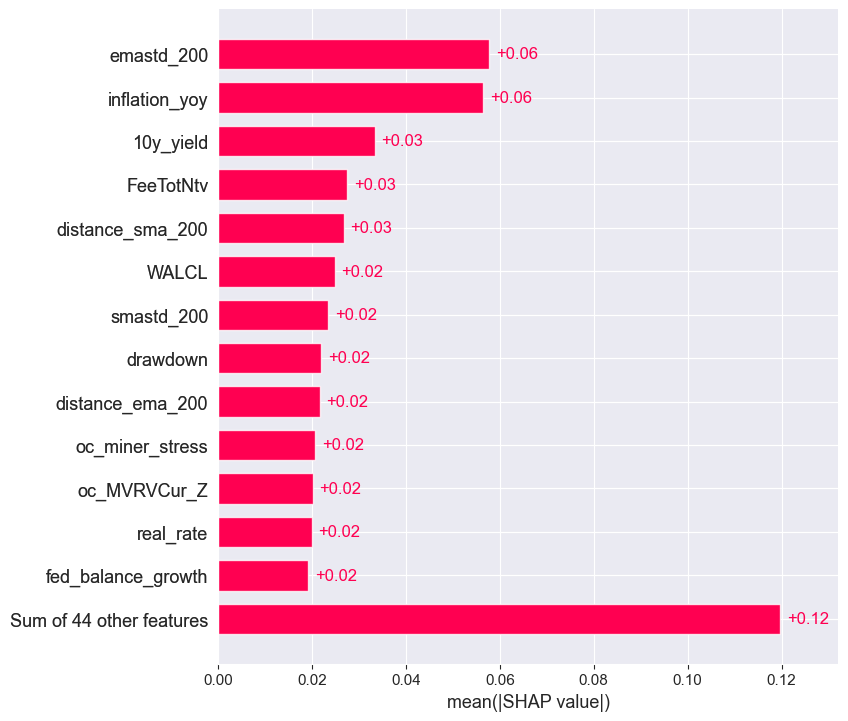

In [496]:
shap.plots.bar(shap_values_LGB, max_display=14)

In [497]:
shap_col_LGB = pl.DataFrame({'colname':X.columns, 'shap':np.abs(shap_values_LGB.values).mean(axis=0)})
shap_col_LGB.with_columns(
    pl.when(pl.col('colname').is_in(POLYMARKET_COL)).then(pl.lit('POLYMARKET'))
    .when(pl.col('colname').is_in(ONCHAIN_FEATURES)).then(pl.lit('ONCHAIN'))
    .when(pl.col('colname').is_in(BINANCE_FEATURES)).then(pl.lit('BINANCE'))
    .when(pl.col('colname').is_in(TECHNICAL_FEATURES)).then(pl.lit('TECHNICAL'))
    .when(pl.col('colname').is_in(MACRO_FEATURES)).then(pl.lit('MACRO'))
    .alias('COL_CATEGORY')
).group_by(pl.col('COL_CATEGORY')).agg(pl.col('shap').sum()/shap_col['shap'].sum())

COL_CATEGORY,shap
str,f64
"""POLYMARKET""",0.0
"""BINANCE""",0.014339
"""TECHNICAL""",0.327949
"""MACRO""",0.407488
"""ONCHAIN""",0.317588


In [ ]:
# Interpreting the results
# Does PolyMarket have predictive power
# Compare only timeframe with polymarket data in/ex poly data
# Clustering does not show meaningful data

## 3. Target change

### 3.1. Top 30% quantile return

In [1124]:
TARGET_COL = "target"

In [1125]:
train, test, ROI_train, ROI_test = train_test_split(btc_df, ROI, test_size=0.1,
                                                                         random_state=42, shuffle=False)

In [1126]:
q = train.select(pl.col("ROI_30d").quantile(0.7)).item()

train = train.with_columns(
    (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
)

test = test.with_columns(
    (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
)

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
X_test = test[FEATURE_COLS]
y_test = test[TARGET_COL]

In [1131]:
model_top30 = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.01,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)

In [1132]:
model_top30.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.3
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [1133]:
rank_top30 = signal.get_rank(model_top30, pl.concat([X_train, X_test], how="vertical"), len(X_train), 30)
ROI_rank_top30 = signal.merge_ROI_rank(ROI, rank_top30)

(-0.5, 2.0)

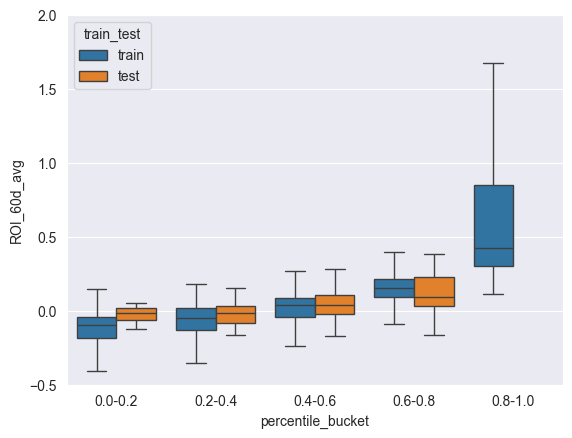

In [1134]:
sns.boxplot(x="percentile_bucket", y="ROI_60d_avg",
            hue="train_test", order=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
            data=ROI_rank_top30, fliersize=0)
plt.ylim(-0.5, 2)

percentile_bucket,train,test
str,f64,f64
"""0.0-0.2""",-0.114449,-0.022414
"""0.2-0.4""",-0.060603,-0.019618
"""0.4-0.6""",0.013323,0.042422
"""0.6-0.8""",0.166782,0.109001
"""0.8-1.0""",0.787994,null


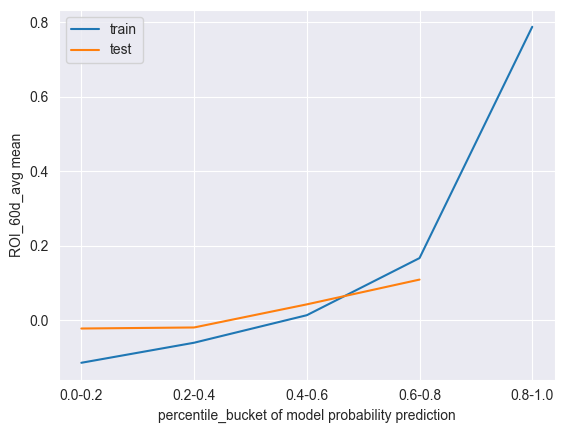

In [1135]:
signal.plot_ROI_by_bucket(ROI_rank_top30)

percentile_bucket,train,test
str,f64,f64
"""0.0-0.2""",0.153352,0.404762
"""0.2-0.4""",0.337173,0.39548
"""0.4-0.6""",0.639196,0.655172
"""0.6-0.8""",0.922269,0.84507
"""0.8-1.0""",1.0,null


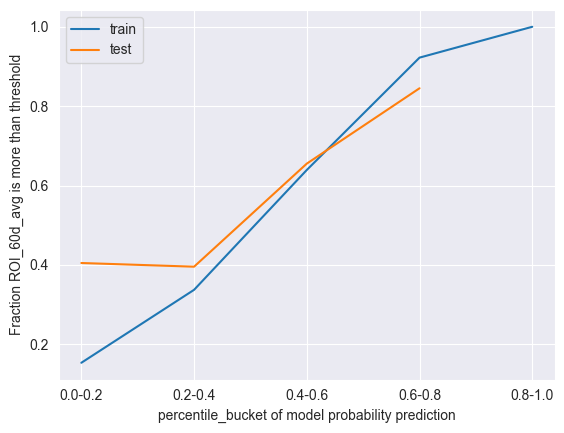

In [1136]:
signal.plot_ROI_threshold(ROI_rank_top30)

### 3.2 distance to future minimum / closeness to bottom

In [1558]:
TARGET_COL = 'Future_60d_min_rel'
X = btc_df[FEATURE_COLS]
y = btc_df[TARGET_COL]
ROI = btc_df[['ROI_60d_avg']]
X_train, X_test, y_train, y_test, ROI_train, ROI_test = train_test_split(X, y, ROI, test_size=0.1,
                                                                         random_state=1, shuffle=False)

In [1559]:
model_min = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.1,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)
model_min.fit(X_train, y_train)
pred_min = model_min.predict(X_test)

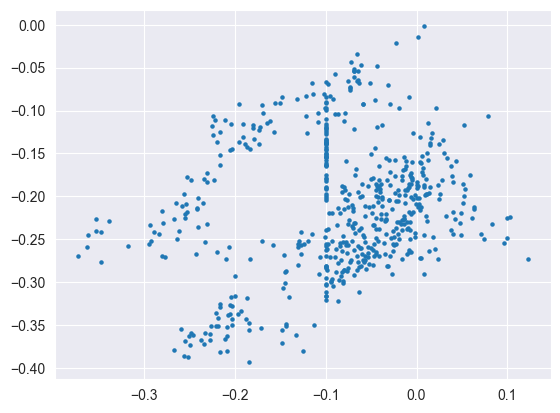

In [1560]:
plt.scatter(y_test, pred_min,s = 5)

In [1561]:
rank = pd.DataFrame(model_min.predict(X)).rank(pct=True)
rank = rank.rename(columns={0: 'percentile'})
rank['train_test'] = 'train'
# rank.iloc[len_train:(len_train+purge_len), rank.columns.get_loc('train_test')] = 'purge'
rank.iloc[(len(X_train)+60):, rank.columns.get_loc('train_test')] = 'test'

In [1562]:
ROI_rank = pl.concat([ROI, pl.from_pandas(rank)], how="horizontal")
p = pl.col('percentile')
ROI_rank = ROI_rank.with_columns(
    pl.when(p > 0.8).then(pl.lit('0.8-1.0'))
    .when(p > 0.6).then(pl.lit('0.6-0.8'))
    .when(p > 0.4).then(pl.lit('0.4-0.6'))
    .when(p > 0.2).then(pl.lit('0.2-0.4'))
    .when(p > 0).then(pl.lit('0.0-0.2'))
    .otherwise(pl.lit('unknown'))
    .alias('percentile_bucket')
)

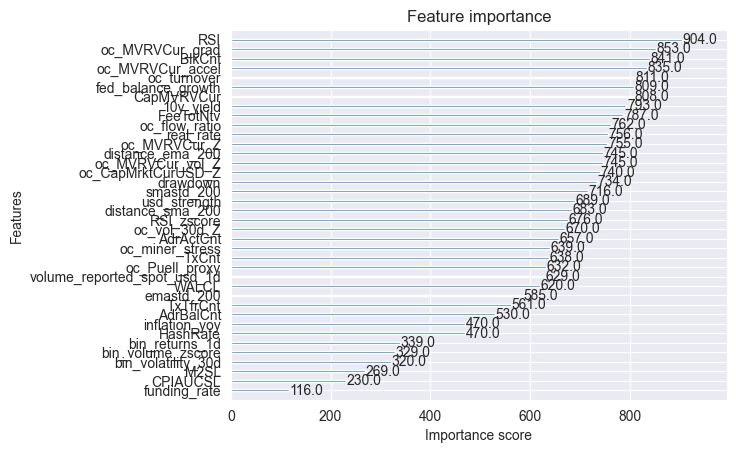

In [1563]:
from xgboost import plot_importance
plot_importance(model_min)
plt.show()

percentile_bucket,train,test
str,f64,f64
"""0.0-0.2""",-0.180609,-0.050826
"""0.2-0.4""",-0.017504,0.059471
"""0.4-0.6""",0.095768,0.038016
"""0.6-0.8""",0.214081,0.055795
"""0.8-1.0""",0.651645,null


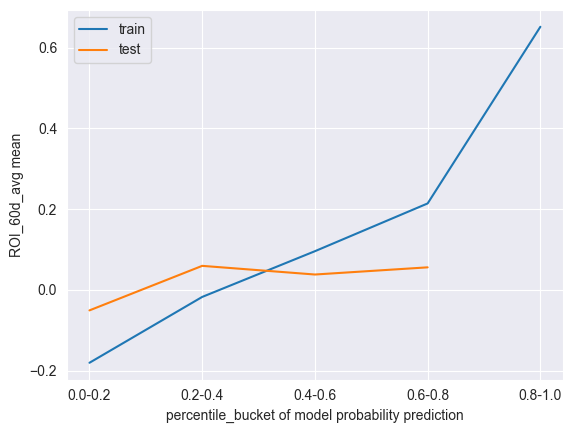

In [1564]:
signal.plot_ROI_by_bucket(ROI_rank)

percentile_bucket,test,train
str,f64,f64
"""0.0-0.2""",0.204545,0.031915
"""0.2-0.4""",0.700935,0.245235
"""0.4-0.6""",0.6,0.631186
"""0.6-0.8""",1.0,0.989371
"""0.8-1.0""",null,1.0


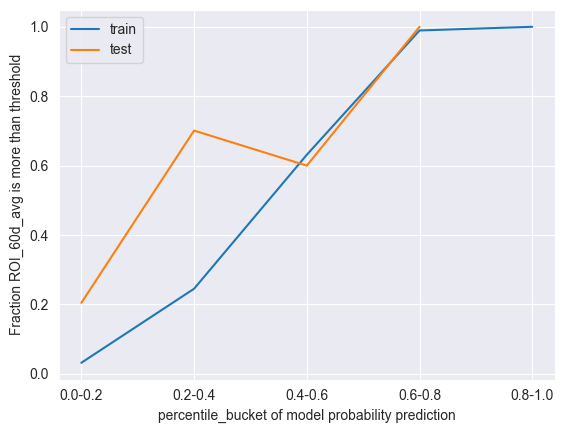

In [1565]:
signal.plot_ROI_threshold(ROI_rank)

In [1566]:
spearmanr(y_test, pred_min, nan_policy='omit')

SignificanceResult(statistic=np.float64(0.1986244002813191), pvalue=np.float64(1.912005045734126e-06))

## 3. Digging into whether Polymarket data has informative value

In [77]:
COLS = btc_df.columns
EXCLUDE_COLS = ['time','future_30d_avg','ROI_30d_avg','target_rank_30d','future_60d_avg','ROI_60d_avg',
                'target_rank_60d','PriceUSD','markPrice',
                'target_up_60d',
                'CapMrktCurUSD',
                #'oc_CapMrktCurUSD_Z',
                ]
TARGET_COL = 'target_up_30d'
INDEX_COL = 'time_basis'

# FEATURE_COLS = 'oc_MVRVCur_Z'
FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL]
POLYMARKET_COL = [
    'poly_dtrade_count',
    'poly_dtrade_active_traders',
    'poly_dtrade_avg_trx',
    'poly_dtrade_trx',
    'poly_dtrade_trx_dir',
    'poly_dtrade_trx_std',
    'odds_markets',
    'odds_avg',
    'odds_dispersion',
    'odds_breadth',
    'odds_momentum',
    'odds_long_market',
    'odds_long_avg',
    'odds_short_market',
    'odds_short_avg',
    'odds_duration_divergence',
    'poly_dtrade_trx_zscore',
    'poly_dtrade_trx_dir_zscore',
    'odds_avg_zscore',
    'odds_long_zscore',
    'odds_short_zscore',
    'poly_dtrade_trx_dir_ratio',
]
NON_POLY_FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL and col not in POLYMARKET_COL]
POLYMARKET_START = pl.date(2025,4,7)

In [78]:
# Only use dataset with polymarket data
btc_df_poly = btc_df.filter(pl.col('time') >= POLYMARKET_START)
Xp2 = btc_df_poly[FEATURE_COLS]
yp = btc_df_poly[TARGET_COL]
ROIp = btc_df_poly[['ROI_30d_avg']]

In [85]:
Xp2_train, Xp2_test, yp_train, yp_test, ROIp_train, ROIp_test = train_test_split(Xp2, yp, ROIp, test_size=0.3,
                                                                         random_state=42, shuffle=False)

In [86]:
model2 = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42
)

In [87]:
model2.fit(Xp2_train, yp_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [88]:
rank2 = signal.get_rank(model2, Xp2, len(Xp2_train), 30)
ROI_rank2 = signal.merge_ROI_rank(ROIp, rank2)

(-0.2, 0.3)

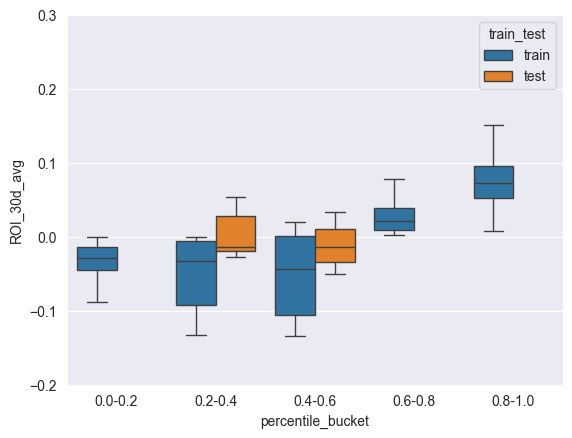

In [90]:
sns.boxplot(x="percentile_bucket", y="ROI_30d_avg",
            hue="train_test", order=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
            data=ROI_rank2, fliersize=0)
plt.ylim(-0.2, 0.3)

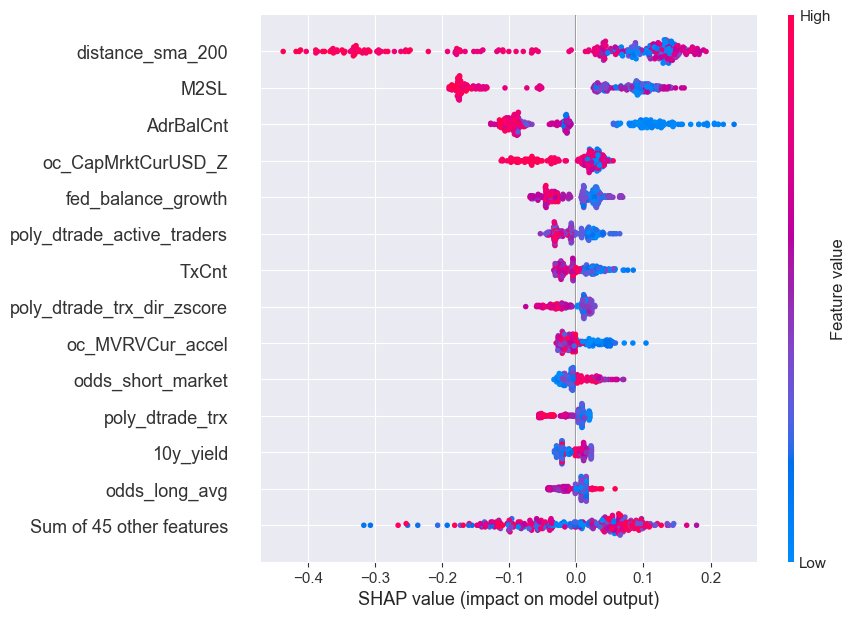

In [91]:
background = Xp2.to_pandas().sample(min(200, len(Xp2)), random_state=42)
background.columns = [str(c) for c in background.columns]

X_shap = Xp2.to_pandas()
X_shap.columns = [str(c) for c in X_shap.columns]

explainer = shap.TreeExplainer(
    model2,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_shap)
shap.plots.beeswarm(shap_values, max_display=14)

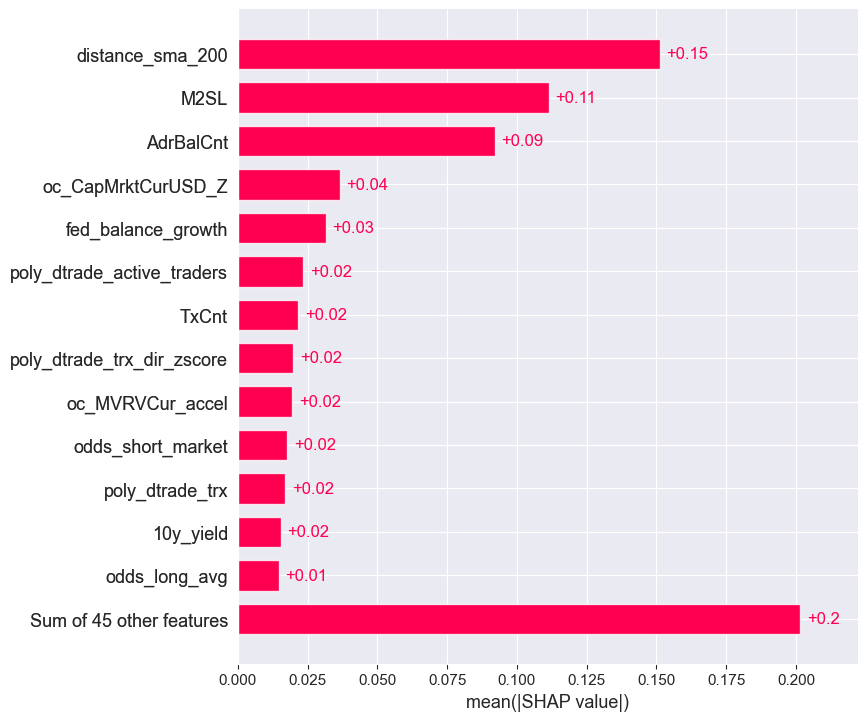

In [92]:
shap.plots.bar(shap_values, max_display=14)

In [100]:
shap_col = pl.DataFrame({'colname':Xp2.columns, 'shap':np.abs(shap_values.values).mean(axis=0)})
shap_col.with_columns(
    pl.when(pl.col('colname').is_in(POLYMARKET_COL)).then(pl.lit('POLYMARKET'))
    .when(pl.col('colname').is_in(ONCHAIN_FEATURES)).then(pl.lit('ONCHAIN'))
    .when(pl.col('colname').is_in(BINANCE_FEATURES)).then(pl.lit('BINANCE'))
    .when(pl.col('colname').is_in(TECHNICAL_FEATURES)).then(pl.lit('TECHNICAL'))
    .when(pl.col('colname').is_in(MACRO_FEATURES)).then(pl.lit('MACRO'))
    .alias('COL_CATEGORY')
).group_by(pl.col('COL_CATEGORY')).agg(pl.col('shap').sum()/shap_col['shap'].sum())

COL_CATEGORY,shap
str,f64
"""POLYMARKET""",0.21551
"""MACRO""",0.232974
"""ONCHAIN""",0.299538
null,0.0
"""TECHNICAL""",0.227026
"""BINANCE""",0.024952


Model is poor because of limited data
Although polymarket has about ~21% explanatory power, it may be random

## 4. Recent data weightage

In [396]:
COLS = btc_df.columns
EXCLUDE_COLS = ['time','future_30d_avg',
                'ROI_30d_avg',
                'target_up_30d',
                'target_up5_30d',
                'future_30d_vs_30d_SMA',
                'future_30d_min',
                'Price_per_30d_min',
                'target_rank_30d',
                'future_60d_avg',
                'ROI_60d_avg',
                'target_up_60d',
                'target_up5_60d',
                'future_60d_vs_30d_SMA',
                'future_60d_min',
                'Price_per_60d_min',
                'target_rank_60d',
                'ROI_30d',
                'ROI_30d_top30',
                'ROI_60d',
                'ROI_60d_top30','PriceUSD','markPrice',
                'target_up_30d',
                'CapMrktCurUSD',
                'oc_MVRV_high',
                # 'smastd_200',
                # 'distance_sma_200'
                #'oc_CapMrktCurUSD_Z',
                ]
TARGET_COL = 'target_up5_60d'
INDEX_COL = 'time_basis'

# FEATURE_COLS = 'oc_MVRVCur_Z'
FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL]
POLYMARKET_COL = [
    'poly_dtrade_count',
    'poly_dtrade_active_traders',
    'poly_dtrade_avg_trx',
    'poly_dtrade_trx',
    'poly_dtrade_trx_dir',
    'poly_dtrade_trx_std',
    'odds_markets',
    'odds_avg',
    'odds_dispersion',
    'odds_breadth',
    'odds_momentum',
    'odds_long_market',
    'odds_long_avg',
    'odds_short_market',
    'odds_short_avg',
    'odds_duration_divergence',
    'poly_dtrade_trx_zscore',
    'poly_dtrade_trx_dir_zscore',
    'odds_avg_zscore',
    'odds_long_zscore',
    'odds_short_zscore',
    'poly_dtrade_trx_dir_ratio',
]
NON_POLY_FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL and col not in POLYMARKET_COL]
POLYMARKET_START = pl.date(2025,4,7)

ONCHAIN_FEATURES = [
    'AdrActCnt',
    'AdrBalCnt',
    'BlkCnt',
    'CapMVRVCur',
    'FeeTotNtv',
    'HashRate',
    'TxCnt',
    'TxTfrCnt',
    'volume_reported_spot_usd_1d',
    'oc_MVRVCur_Z',
    'oc_MVRVCur_grad',
    'oc_MVRVCur_accel',
    'oc_CapMrktCurUSD_Z',
    'oc_Puell_proxy',
    'oc_miner_stress',
    'oc_flow_ratio',
    'oc_vol_30d_zscore',
    'oc_turnover',
]
TECHNICAL_FEATURES = [
    'smastd_200',
    'distance_sma_200',
    'emastd_200',
    'distance_ema_200',
    'drawdown',
]
MACRO_FEATURES = [
    'M2SL',
    'WALCL',
    'CPIAUCSL',
    'fed_balance_growth',
    'real_rate',
    'usd_strength',
    '10y_yield',
    'inflation_yoy'
]
BINANCE_FEATURES = [
    'bin_returns_1d',
    'bin_volatility_30d',
    'bin_volume_zscore',
    'funding_rate'
]

Which target should I use?
Binary / categorized returns

Should I put higher weight on more recent samples? sample_weight in XGBoost
Alternative method = create 2 models and proportion them


In [397]:
X = btc_df[FEATURE_COLS]
y = btc_df[TARGET_COL]
ROI = btc_df[['ROI_60d_avg']]
X_train, X_test, y_train, y_test, ROI_train, ROI_test = train_test_split(X, y, ROI, test_size=0.2,
                                                                         random_state=42, shuffle=False)

In [398]:
model3 = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.6, learning_rate= 0.01,
    max_depth= 7, n_estimators= 300,
    reg_alpha= 1, reg_lambda= 2, subsample= 0.6
)
# {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.6}

In [129]:
# Assume 30% decay rate
ANNUAL_DECAY = 0.3
multiplier = (1+ANNUAL_DECAY)**(1/365)
model3.fit(X_train, y_train, sample_weight=multiplier**np.arange(len(y_train)))

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
plt.hist(model3.predict_proba(X_test)[:,1])

In [130]:
rank3 = signal.get_rank(model3, X, len(X_train), 60)
ROI_rank3 = signal.merge_ROI_rank(ROI, rank3)

(-0.5, 1.5)

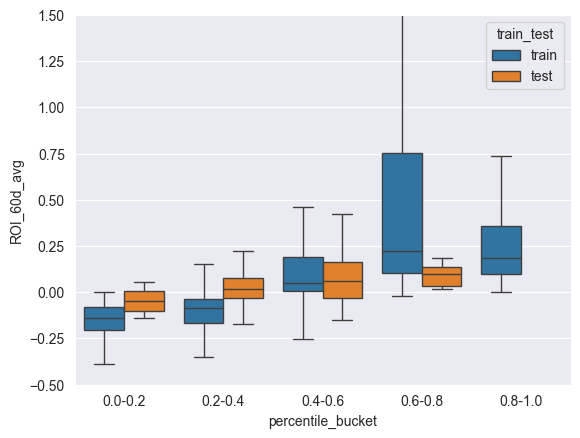

In [131]:
sns.boxplot(x="percentile_bucket", y="ROI_60d_avg",
            hue="train_test", order=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'],
            data=ROI_rank3, fliersize=0)
plt.ylim(-0.5, 1.5)

(-1.0, 1.0)

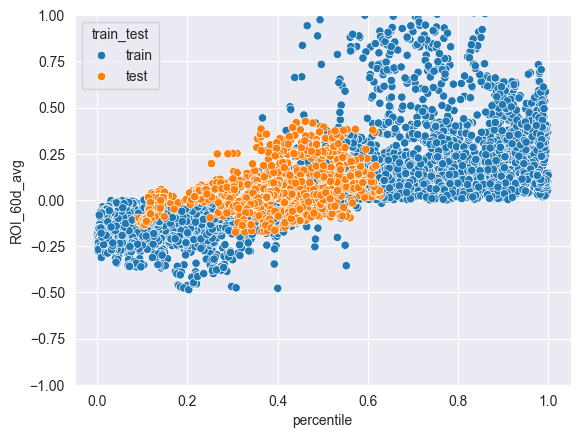

In [132]:
sns.scatterplot(ROI_rank3, x="percentile", y="ROI_60d_avg", hue="train_test")
plt.ylim(-1, 1)

percentile_bucket,test,train
str,f64,f64
"""0.0-0.2""",-0.045468,-0.147986
"""0.2-0.4""",0.028705,-0.107744
"""0.4-0.6""",0.08224,0.159369
"""0.6-0.8""",0.107952,0.640233
"""0.8-1.0""",null,0.241129


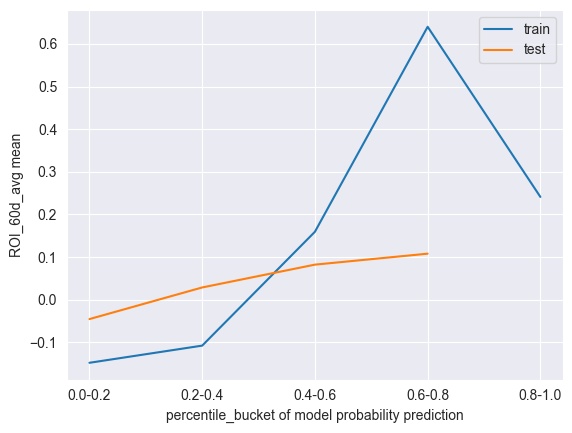

In [134]:
signal.plot_ROI_by_bucket(ROI_rank3)

percentile_bucket,test,train
str,f64,f64
"""0.0-0.2""",0.287234,0.0
"""0.2-0.4""",0.597052,0.081232
"""0.4-0.6""",0.683027,0.828571
"""0.6-0.8""",1.0,0.999098
"""0.8-1.0""",null,1.0


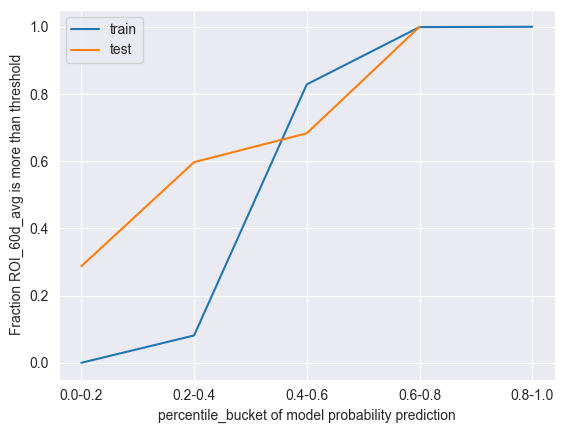

In [135]:
signal.plot_ROI_threshold(ROI_rank3,0)

## 5. Preparing FEATURES_DF for backtest

### Standard

* Monthly fit XGBoost. Various weights (0%/10%/20%/30% decay)
* Percentile score relative to historical prediction updated for each row

In [181]:
COLS = btc_df.columns
EXCLUDE_COLS = ['time','future_30d_avg','ROI_30d_avg','target_rank_30d','future_60d_avg','ROI_60d_avg',
                'target_rank_60d','PriceUSD','markPrice',
                'target_up_30d',
                'CapMrktCurUSD',
                'oc_MVRV_high',
                # 'smastd_200',
                # 'distance_sma_200'
                #'oc_CapMrktCurUSD_Z',
                ]
TARGET_COL = 'target_up_60d'
INDEX_COL = 'time_basis'

# FEATURE_COLS = 'oc_MVRVCur_Z'
FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL]
POLYMARKET_COL = [
    'poly_dtrade_count',
    'poly_dtrade_active_traders',
    'poly_dtrade_avg_trx',
    'poly_dtrade_trx',
    'poly_dtrade_trx_dir',
    'poly_dtrade_trx_std',
    'odds_markets',
    'odds_avg',
    'odds_dispersion',
    'odds_breadth',
    'odds_momentum',
    'odds_long_market',
    'odds_long_avg',
    'odds_short_market',
    'odds_short_avg',
    'odds_duration_divergence',
    'poly_dtrade_trx_zscore',
    'poly_dtrade_trx_dir_zscore',
    'odds_avg_zscore',
    'odds_long_zscore',
    'odds_short_zscore',
    'poly_dtrade_trx_dir_ratio',
]
NON_POLY_FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL and col not in POLYMARKET_COL]
POLYMARKET_START = pl.date(2025,4,7)

ONCHAIN_FEATURES = [
    'AdrActCnt',
    'AdrBalCnt',
    'BlkCnt',
    'CapMVRVCur',
    'FeeTotNtv',
    'HashRate',
    'TxCnt',
    'TxTfrCnt',
    'volume_reported_spot_usd_1d',
    'oc_MVRVCur_Z',
    'oc_MVRVCur_grad',
    'oc_MVRVCur_accel',
    'oc_CapMrktCurUSD_Z',
    'oc_Puell_proxy',
    'oc_miner_stress',
    'oc_flow_ratio',
    'oc_vol_30d_zscore',
    'oc_turnover',
]
TECHNICAL_FEATURES = [
    'smastd_200',
    'distance_sma_200',
    'emastd_200',
    'distance_ema_200',
    'drawdown',
]
MACRO_FEATURES = [
    'M2SL',
    'WALCL',
    'CPIAUCSL',
    'fed_balance_growth',
    'real_rate',
    'usd_strength',
    '10y_yield',
    'inflation_yoy'
]
BINANCE_FEATURES = [
    'bin_returns_1d',
    'bin_volatility_30d',
    'bin_volume_zscore',
    'funding_rate'
]

In [339]:
DATA_START = btc_df['time_basis'].min()
DATA_END = btc_df['time_basis'].max()
BACKTEST_START = date(2018, 1, 1)
CYCLE_LENGTH = 90
PURGE_LEN = 60

In [340]:
cycles = pl.date_range(
    start=BACKTEST_START,
    end=DATA_END,
    interval=str(CYCLE_LENGTH)+"d",
    eager=True
).alias("cycles")

In [399]:
model_cycle = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.6, learning_rate= 0.01,
    max_depth= 3, n_estimators= 500,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.6
)

In [400]:
# Try a few values from 0.1 to 0.3
ANNUAL_DECAY = [0.0, 0.3] #, 0.1, 0.2, 0.3

In [401]:
STRAT_WEIGHTS = {'RANK_DECAY_'+str(key): np.array([]) for key in ANNUAL_DECAY}

for start_cycle in cycles:
    end_cycle = start_cycle + timedelta(days=CYCLE_LENGTH)
    train = btc_df.filter(pl.col('time_basis') < (start_cycle)) # ensure no leakage -timedelta(days=PURGE_LEN)
    test = btc_df.filter((pl.col('time_basis') >= start_cycle)&(pl.col('time_basis') < end_cycle))
    X_train = train[FEATURE_COLS]
    X_test = test[FEATURE_COLS]
    y_train = train[TARGET_COL]
    y_test = test[TARGET_COL]
    X = pl.concat([X_train, X_test], how="vertical")

    for DECAY in ANNUAL_DECAY:
        KEY = 'RANK_DECAY_'+str(DECAY)
        multiplier = (1+DECAY)**(1/365)
        model_cycle.fit(X_train, y_train, sample_weight=multiplier**np.arange(len(y_train)))
        # rank = signal.get_rank(model_cycle, X, len(X_train), PURGE_LEN)
        # STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank['percentile'][-len(test):]))

        rank = model_cycle.predict_proba(X_test)[:,1]
        STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank[-len(test):]))


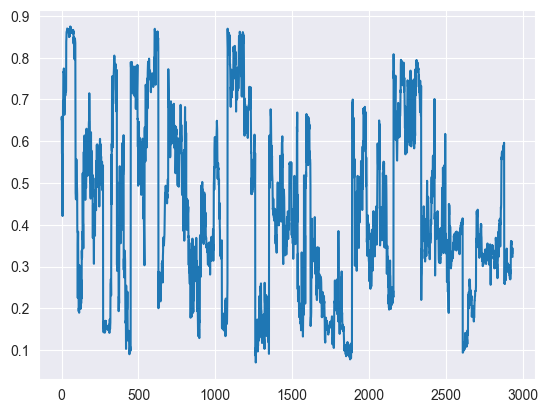

In [402]:
plt.plot(STRAT_WEIGHTS['RANK_DECAY_0.0'])

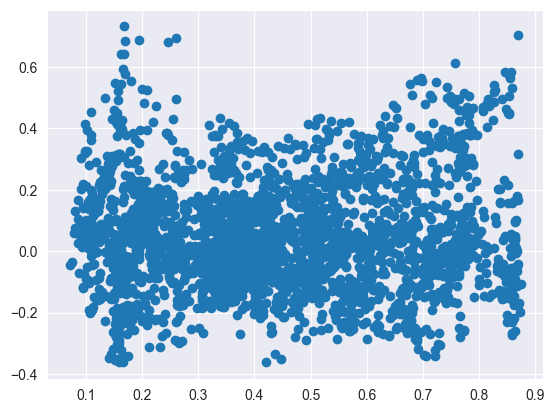

In [403]:
plt.scatter(STRAT_WEIGHTS['RANK_DECAY_0.0'], ROI_backtest)

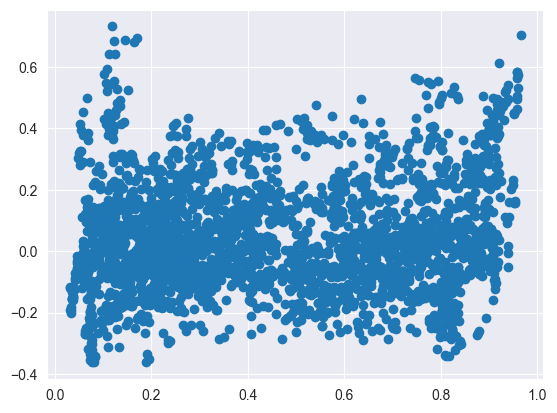

In [404]:
plt.scatter(STRAT_WEIGHTS['RANK_DECAY_0.3'], ROI_backtest)

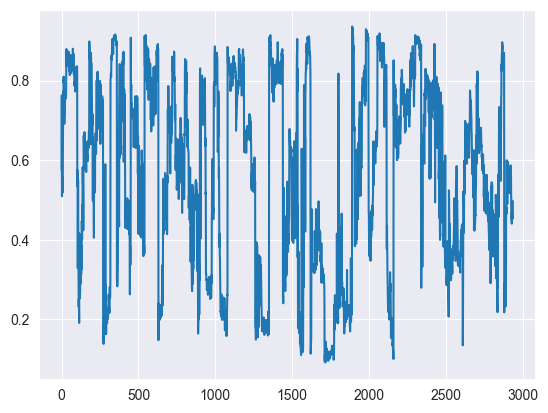

In [379]:
plt.plot(STRAT_WEIGHTS['RANK_DECAY_0.0'])

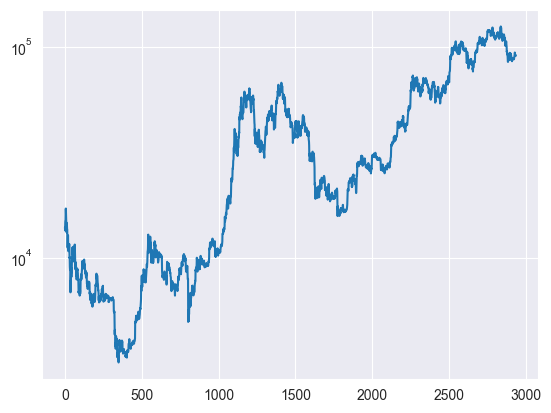

In [348]:
plt.semilogy(Price)

In [ ]:
btc_df.

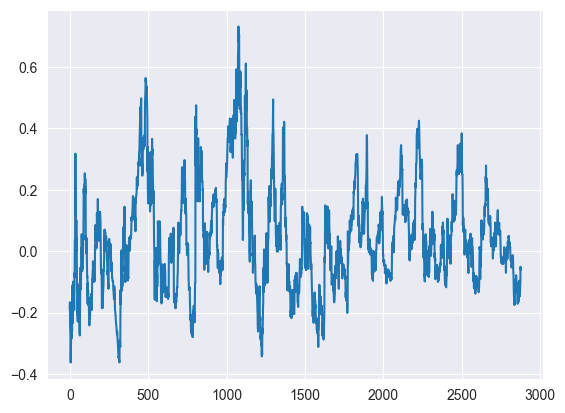

In [365]:
Price = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['PriceUSD']].to_pandas()
ROI_backtest = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['ROI_60d_avg']].to_pandas()
STRAT_WEIGHTS = pd.DataFrame(STRAT_WEIGHTS)

In [367]:
rank_colname = 'RANK_DECAY_0.3'

ROI_rank = signal.merge_ROI_rank(
    pl.from_pandas(ROI_backtest),
    STRAT_WEIGHTS[[rank_colname]].rename(columns={rank_colname:'percentile'})
)
ROI_colname = ROI_rank.select(pl.col('^ROI.*$')).columns[0]
grouped = (
    ROI_rank.filter(pl.col(ROI_colname).is_not_null())
    .group_by(['percentile_bucket'])
    .agg(pl.col(ROI_colname).mean())
    .sort('percentile_bucket')
)
display(grouped)

percentile_bucket,ROI_60d_avg
str,f64
"""0.0-0.2""",0.009535
"""0.2-0.4""",0.02553
"""0.4-0.6""",0.043157
"""0.6-0.8""",0.028729
"""0.8-1.0""",0.065144


In [369]:
ROI_colname = ROI_rank.select(pl.col('^ROI.*$')).columns[0]
grouped = (
    ROI_rank.filter(pl.col(ROI_colname).is_not_null())
    .group_by(['percentile_bucket'])
    .agg((pl.col(ROI_colname) > 0).mean())
    .sort('percentile_bucket')
)
display(grouped)

percentile_bucket,ROI_60d_avg
str,f64
"""0.0-0.2""",0.416309
"""0.2-0.4""",0.553525
"""0.4-0.6""",0.605081
"""0.6-0.8""",0.555777
"""0.8-1.0""",0.602013


In [372]:
Time = btc_df[['time_basis']].filter(pl.col('time_basis') >= pl.date(2018,1,1)).rename({'time_basis':'time'}).to_pandas()
STRAT_WEIGHTS_ = pd.concat([Time, STRAT_WEIGHTS],axis=1)
STRAT_WEIGHTS_.set_index('time', inplace=True)
STRAT_WEIGHTS_.index = STRAT_WEIGHTS_.index.normalize().tz_localize(None)


In [378]:
STRAT_WEIGHTS_['RANK_DECAY_0.0']

time
2018-01-01    0.574447
2018-01-02    0.763046
2018-01-03    0.509390
2018-01-04    0.536688
2018-01-05    0.526944
                ...   
2026-01-09    0.468653
2026-01-10    0.462230
2026-01-11    0.454277
2026-01-12    0.498256
2026-01-13    0.452441
Freq: D, Name: RANK_DECAY_0.0, Length: 2935, dtype: float64

In [377]:
STRAT_WEIGHTS_['RANK_DECAY_0.0'].rolling(window=3).mean()

time
2018-01-01         NaN
2018-01-02         NaN
2018-01-03    0.615628
2018-01-04    0.603041
2018-01-05    0.524340
                ...   
2026-01-09    0.454140
2026-01-10    0.457143
2026-01-11    0.461720
2026-01-12    0.471588
2026-01-13    0.468325
Freq: D, Name: RANK_DECAY_0.0, Length: 2935, dtype: float64

In [373]:
STRAT_WEIGHTS_.to_parquet('XGB_WEIGHTS.parquet', compression='zstd')

### 5.2 Return quantile

In [1273]:
TARGET_COL = "target"
DATA_START = btc_df['time_basis'].min()
DATA_END = btc_df['time_basis'].max()
BACKTEST_START = date(2017, 1, 1)
CYCLE_LENGTH = 5
PURGE_LEN = 30
cycles = pl.date_range(
    start=BACKTEST_START,
    end=DATA_END,
    interval=str(CYCLE_LENGTH)+"d",
    eager=True
).alias("cycles")
model_cycle = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.01,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)
# Try a few values from 0.1 to 0.3
ANNUAL_DECAY = [0.0] #, 0.1, 0.2, 0.3

In [1268]:
STRAT_WEIGHTS_Q = {'RANK_DECAY_'+str(key): np.array([]) for key in ANNUAL_DECAY}

for start_cycle in cycles:
    end_cycle = start_cycle + timedelta(days=CYCLE_LENGTH)
    train = btc_df.filter(pl.col('time_basis') < (start_cycle-timedelta(days=PURGE_LEN))) # ensure no leakage -timedelta(days=PURGE_LEN)
    test = btc_df.filter((pl.col('time_basis') >= start_cycle)&(pl.col('time_basis') < end_cycle))
    q = train.select(pl.col("ROI_30d").quantile(0.7)).item()

    train = train.with_columns(
        (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
    )

    test = test.with_columns(
        (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
    )

    X_train = train[FEATURE_COLS]
    X_test = test[FEATURE_COLS]
    y_train = train[TARGET_COL].fill_null(0)
    y_test = test[TARGET_COL].fill_null(0)
    X = pl.concat([X_train, X_test], how="vertical")

    for DECAY in ANNUAL_DECAY:
        KEY = 'RANK_DECAY_'+str(DECAY)
        multiplier = (1+DECAY)**(1/365)
        model_cycle.fit(X_train, y_train, sample_weight=multiplier**np.arange(len(y_train)))
        # rank = signal.get_rank(model_cycle, X, len(X_train), PURGE_LEN)
        # STRAT_WEIGHTS_Q[KEY] = np.append(STRAT_WEIGHTS_Q[KEY],(rank['percentile'][-len(test):]))

        rank = model_cycle.predict_proba(X_test)[:,1]
        STRAT_WEIGHTS_Q[KEY] = np.append(STRAT_WEIGHTS_Q[KEY],(rank[-len(test):]))
STRAT_WEIGHTS_Q = pd.DataFrame(STRAT_WEIGHTS_Q)


In [1275]:
Price = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['PriceUSD']].to_pandas()
ROI_backtest = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['ROI_60d_avg']].to_pandas()

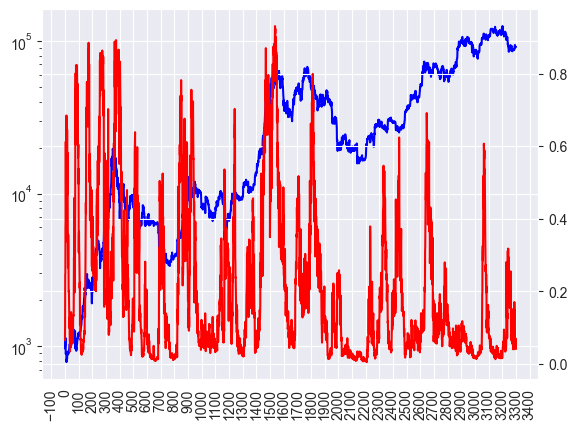

In [1276]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

fig, ax1 = plt.subplots()

# First plot (Left Y-axis)
ax1.semilogy(Price, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(STRAT_WEIGHTS_Q['RANK_DECAY_0.0'], color='red')

ax1.xaxis.set_major_locator(MultipleLocator(100))
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)


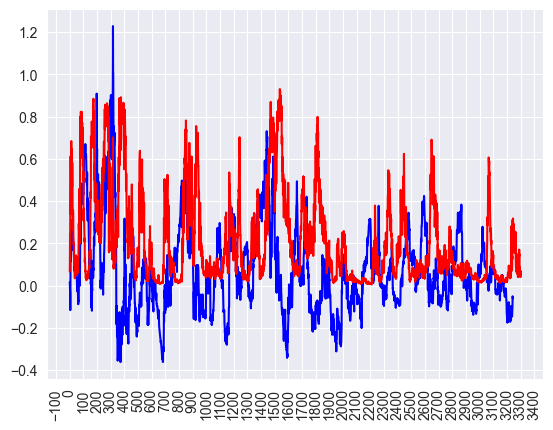

In [1277]:
fig, ax1 = plt.subplots()

# First plot (Left Y-axis)
ax1.plot(ROI_backtest, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax1.plot(STRAT_WEIGHTS_Q['RANK_DECAY_0.0'], color='red')

ax1.xaxis.set_major_locator(MultipleLocator(100))
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)


Seems able to pred

In [1355]:
series=pl.from_pandas(STRAT_WEIGHTS_Q['RANK_DECAY_0.0'])
window = 365
mean = series.rolling_mean(window_size=window, min_periods=window // 2)
std = series.rolling_std(window_size=window, min_periods=window // 2)
prob_top30_z = pl.DataFrame((series - mean) / std).rename({'RANK_DECAY_0.0':'prob_top30_zscore'})

In [1313]:
spearmanr(prob_70_z, ROI_backtest, nan_policy='omit')

SignificanceResult(statistic=np.float64(0.17391748433567178), pvalue=np.float64(3.253401052001356e-22))

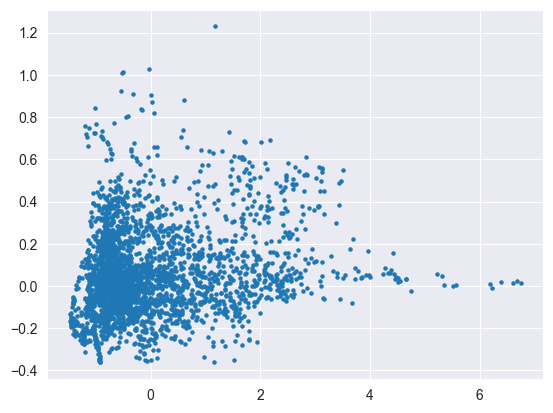

In [1312]:
plt.scatter(prob_70_z, ROI_backtest, s=5)

In [1356]:
ROI_rank = pl.concat([pl.from_pandas(ROI_backtest), prob_top30_z], how="horizontal")

In [1386]:
(prob_top30_z>0.1).sum()

prob_top30_zscore
u32
956


In [1357]:
p = pl.col('prob_top30_zscore')
(ROI_rank.with_columns(
    pl.when(p > 2).then(pl.lit('2 and above'))
    .when(p > 1).then(pl.lit('1 to 2'))
    .when(p > 0).then(pl.lit('0 to 1'))
    .when(p > -1).then(pl.lit('-1 to 0'))
    .when(p > -2).then(pl.lit('-2 to -1'))
    .otherwise(pl.lit('unknown'))
    .alias('z_bucket')
).filter(p.is_not_null())
             .group_by(['z_bucket'])
             .agg(pl.col("ROI_60d_avg").mean()))

z_bucket,ROI_60d_avg
str,f64
"""-1 to 0""",0.055222
"""0 to 1""",0.062331
"""-2 to -1""",-0.046535
"""2 and above""",0.170896
"""1 to 2""",0.111012


In [1358]:
(ROI_rank.with_columns(
    pl.when(p > 2).then(pl.lit('2 and above'))
    .when(p > 1).then(pl.lit('1 to 2'))
    .when(p > 0).then(pl.lit('0 to 1'))
    .when(p > -1).then(pl.lit('-1 to 0'))
    .when(p > -2).then(pl.lit('-2 to -1'))
    .otherwise(pl.lit('unknown'))
    .alias('z_bucket')
).filter(p.is_not_null())
             .group_by(['z_bucket'])
             .agg((pl.col("ROI_60d_avg")>0).mean()))

z_bucket,ROI_60d_avg
str,f64
"""2 and above""",0.837004
"""-1 to 0""",0.574648
"""-2 to -1""",0.298969
"""1 to 2""",0.621818
"""0 to 1""",0.59432


In [1235]:
temp = btc_df.filter((pl.col('time_basis') >= (BACKTEST_START-timedelta(days=365)))&(pl.col('time_basis') < BACKTEST_START))[['ROI_30d_top30']].to_pandas().rename(columns={'ROI_30d_top30':'prob_top30'})

In [1361]:
prob_top30 = STRAT_WEIGHTS_Q.rename(columns={rank_colname:'prob_top30'})
prob_top30 = pd.concat([prob_top30, prob_top30_z.to_pandas()], axis=1)
prob_top30.set_index(btc_df.filter(pl.col('time_basis') >= BACKTEST_START)['time_basis'].to_pandas(), inplace=True)
prob_top30.index.name = 'time'

In [1362]:
prob_top30.to_parquet('prob_top30.parquet')

### 5.3 Min

In [1567]:
TARGET_COL = 'Future_60d_min_rel'

DATA_START = btc_df['time_basis'].min()
DATA_END = btc_df['time_basis'].max()
BACKTEST_START = date(2017, 1, 1)
CYCLE_LENGTH = 90
PURGE_LEN = 60
cycles = pl.date_range(
    start=BACKTEST_START,
    end=DATA_END,
    interval=str(CYCLE_LENGTH)+"d",
    eager=True
).alias("cycles")
model_cycle = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.1,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)
# Try a few values from 0.1 to 0.3
ANNUAL_DECAY = [0.0] #, 0.1, 0.2, 0.3

In [1568]:
STRAT_WEIGHTS = {'TARGET_DECAY_'+str(key): np.array([]) for key in ANNUAL_DECAY}

for start_cycle in cycles:
    end_cycle = start_cycle + timedelta(days=CYCLE_LENGTH)
    train = btc_df.filter(pl.col('time_basis') < (start_cycle-timedelta(days=PURGE_LEN))) # ensure no leakage -timedelta(days=PURGE_LEN)
    test = btc_df.filter((pl.col('time_basis') >= start_cycle)&(pl.col('time_basis') < end_cycle))
    X_train = train[FEATURE_COLS]
    X_test = test[FEATURE_COLS]
    y_train = train[TARGET_COL].fill_null(0)
    y_test = test[TARGET_COL].fill_null(0)
    X = pl.concat([X_train, X_test], how="vertical")

    for DECAY in ANNUAL_DECAY:
        KEY = 'TARGET_DECAY_'+str(DECAY)
        multiplier = (1+DECAY)**(1/365)
        model_cycle.fit(X_train, y_train, sample_weight=multiplier**np.arange(len(y_train)))
        # rank = signal.get_rank(model_cycle, X, len(X_train), PURGE_LEN)
        # STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank['percentile'][-len(test):]))

        rank = model_cycle.predict(X_test)
        STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank[-len(test):]))
STRAT_WEIGHTS = pd.DataFrame(STRAT_WEIGHTS)


In [1569]:
Price = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['PriceUSD']].to_pandas()
ROI_backtest = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['ROI_30d_avg']].to_pandas()

In [1570]:
y_test = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[TARGET_COL].fill_null(0.8)

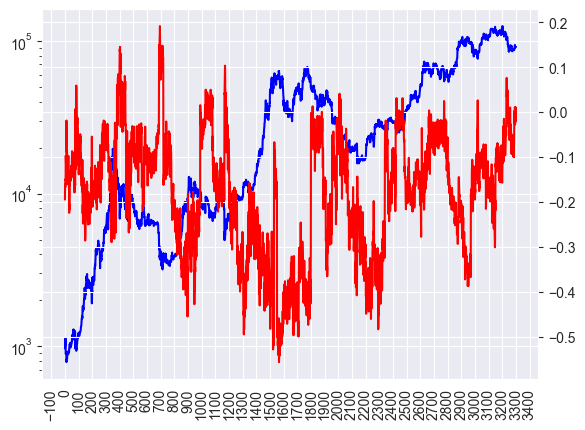

In [1571]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

fig, ax1 = plt.subplots()

# First plot (Left Y-axis)
ax1.semilogy(Price, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(STRAT_WEIGHTS['TARGET_DECAY_0.0'], color='red')

ax1.xaxis.set_major_locator(MultipleLocator(100))
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)

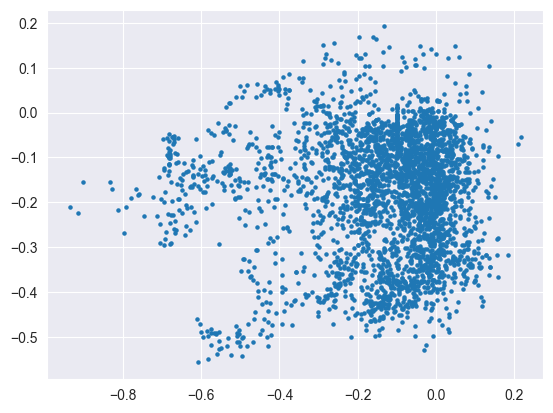

In [1572]:
plt.scatter(y_test,STRAT_WEIGHTS[['TARGET_DECAY_0.0']], s=5)

In [1573]:
min_ratio_log_pred = STRAT_WEIGHTS[['TARGET_DECAY_0.0']].rename(columns={'TARGET_DECAY_0.0':'min_ratio_log_pred'})

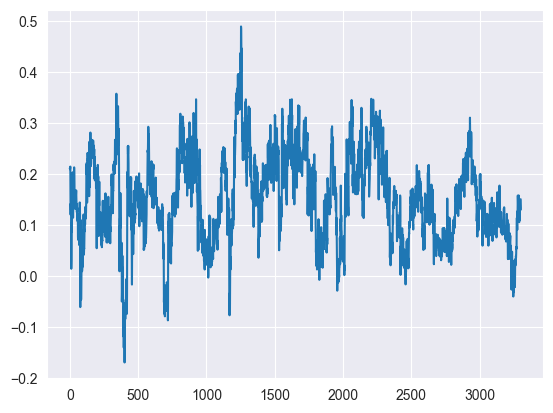

In [1496]:
plt.plot(min_gap)

In [1586]:
series = pl.from_pandas(min_ratio_log_pred['min_ratio_log_pred'])
window = 365
mean = series.rolling_mean(window_size=window, min_periods=window // 2)
std = series.rolling_std(window_size=window, min_periods=window // 2)
min_ratio_log_pred_zscore = pd.DataFrame((series - mean) / std).rename(columns={0:'min_ratio_log_pred_zscore'})

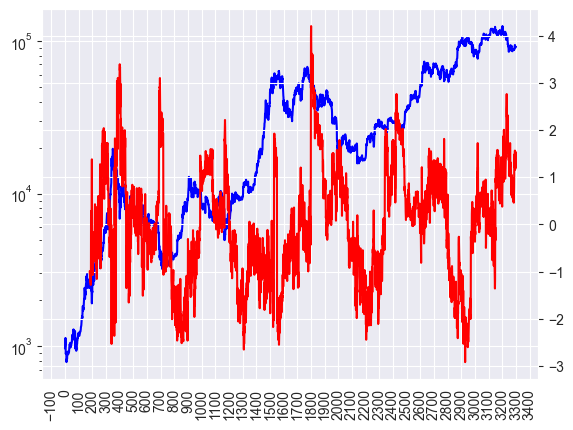

In [1577]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

fig, ax1 = plt.subplots()

# First plot (Left Y-axis)
ax1.semilogy(Price, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(min_ratio_log_pred_zscore, color='red')

ax1.xaxis.set_major_locator(MultipleLocator(100))
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)

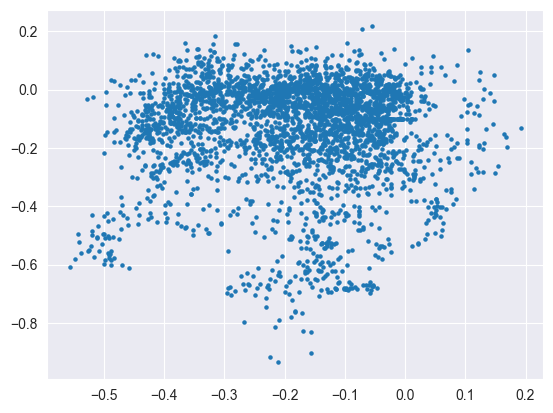

In [1580]:
plt.scatter(min_ratio_log_pred,y_test, s=5)

In [1588]:
min_ratio_log_pred_zscore.set_index(btc_df.filter(pl.col('time_basis') >= BACKTEST_START)['time_basis'].to_pandas(), inplace=True)
min_ratio_log_pred_zscore.index.name = 'time'

In [1589]:
min_ratio_log_pred_zscore.to_parquet('min_gap.parquet')

In [1590]:
min_ratio_log_pred.set_index(btc_df.filter(pl.col('time_basis') >= BACKTEST_START)['time_basis'].to_pandas(), inplace=True)
min_ratio_log_pred.index.name = 'time'
min_ratio_log_pred.to_parquet('min_gap.parquet')

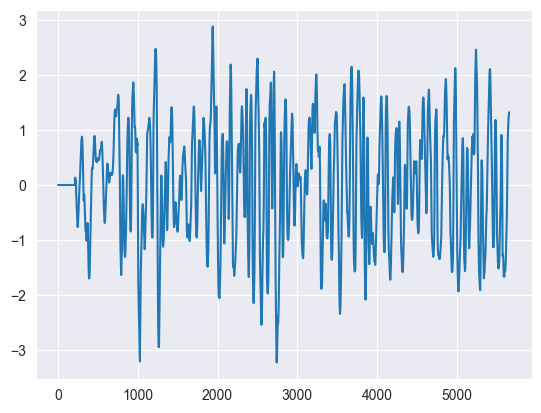

In [1253]:
plt.plot(btc_df['oc_MVRVCur_accel']+btc_df['oc_MVRVCur_grad'])

In [1597]:
btc_df['oc_MVRVCur_grad']

oc_MVRVCur_grad
f64
0.0
0.0
0.0
0.0
0.0
…
0.26475
0.270584
0.288273


In [1598]:
btc_df[['oc_MVRVCur_Z']]

oc_MVRVCur_Z
f64
0.0
0.0
0.0
0.0
0.0
…
-1.772495
-1.768737
-1.733451


In [1606]:
btc_df[['ROI_30d']].quantile(0.7)

ROI_30d
f64
0.158094


In [1595]:
btc_df[['oc_MVRVCur_Z','oc_MVRVCur_grad','oc_MVRVCur_accel ','RSI']]

oc_MVRVCur_Z,oc_MVRVCur_grad,oc_MVRVCur_accel,RSI
f64,f64,f64,f64
0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0
…,…,…,…
-1.772495,0.26475,0.980591,51.859956
-1.768737,0.270584,0.978523,51.339788
-1.733451,0.288273,0.97607,52.534788
